In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("/Users/alex/Downloads/esa-adb-challenge (1)/train.parquet")
print(df.shape)
print(df.dtypes)
df.head(5)

(14728321, 89)
id                   int64
channel_1          float32
channel_10         float32
channel_11         float32
channel_12         float32
                    ...   
telecommand_376    float64
telecommand_38     float64
telecommand_39     float64
telecommand_40     float64
is_anomaly           uint8
Length: 89, dtype: object


,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
0,0,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,4,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
print(df.shape)
print(df.columns.tolist())

(14728321, 89)
['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_3', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_4', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_5', 'channel_50', 'channel_51', 'channel_52', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_57', 'channel_58', 'channel_59', 'channel_6', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_64', 'channel_65', 'channel_66', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_70', 'channel_71', 'channel_72', 'chan

In [5]:
print(df.dtypes)
print(df.isnull().sum())

id                   int64
channel_1          float32
channel_10         float32
channel_11         float32
channel_12         float32
                    ...   
telecommand_376    float64
telecommand_38     float64
telecommand_39     float64
telecommand_40     float64
is_anomaly           uint8
Length: 89, dtype: object
id                 0
channel_1          0
channel_10         0
channel_11         0
channel_12         0
                  ..
telecommand_376    0
telecommand_38     0
telecommand_39     0
telecommand_40     0
is_anomaly         0
Length: 89, dtype: int64


In [6]:
df['is_anomaly'].value_counts(normalize=True)

is_anomaly
0    0.895161
1    0.104839
Name: proportion, dtype: float64

EDA

In [7]:
cols = ['id', 'channel_41', 'channel_42', 'channel_43',
        'channel_44', 'channel_45', 'channel_46', 'is_anomaly']

df_small = df[cols]
print(df_small.shape)
df_small.head()

(14728321, 8)


,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46,is_anomaly
0,0,0.812578,0.786344,0.771900,0.799178,0.816855,0.765296,0
1,1,0.812578,0.786344,0.771900,0.799178,0.816855,0.765296,0
2,2,0.821213,0.789557,0.770317,0.809411,0.816006,0.765296,0
3,3,0.819642,0.786344,0.770317,0.807050,0.816855,0.766985,0
4,4,0.821996,0.788753,0.770317,0.807837,0.818551,0.761073,0


In [8]:
df_small.describe()

,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46,is_anomaly
count,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07
mean,7.364160e+06,8.082077e-01,7.821209e-01,7.685694e-01,7.940099e-01,8.103804e-01,7.656219e-01,1.048391e-01
std,4.251700e+06,3.117312e-02,3.104107e-02,3.194150e-02,3.466514e-02,3.144005e-02,3.055148e-02,3.063460e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.682080e+06,8.055143e-01,7.783114e-01,7.663610e-01,7.913063e-01,8.066803e-01,7.610731e-01,0.000000e+00
50%,7.364160e+06,8.094388e-01,7.831301e-01,7.703173e-01,7.960299e-01,8.117668e-01,7.669848e-01,0.000000e+00
75%,1.104624e+07,8.141486e-01,7.895566e-01,7.742736e-01,8.007520e-01,8.168547e-01,7.728950e-01,0.000000e+00
max,1.472832e+07,9.821104e-01,9.662727e-01,9.507276e-01,9.755059e-01,1.000000e+00,9.595303e-01,1.000000e+00


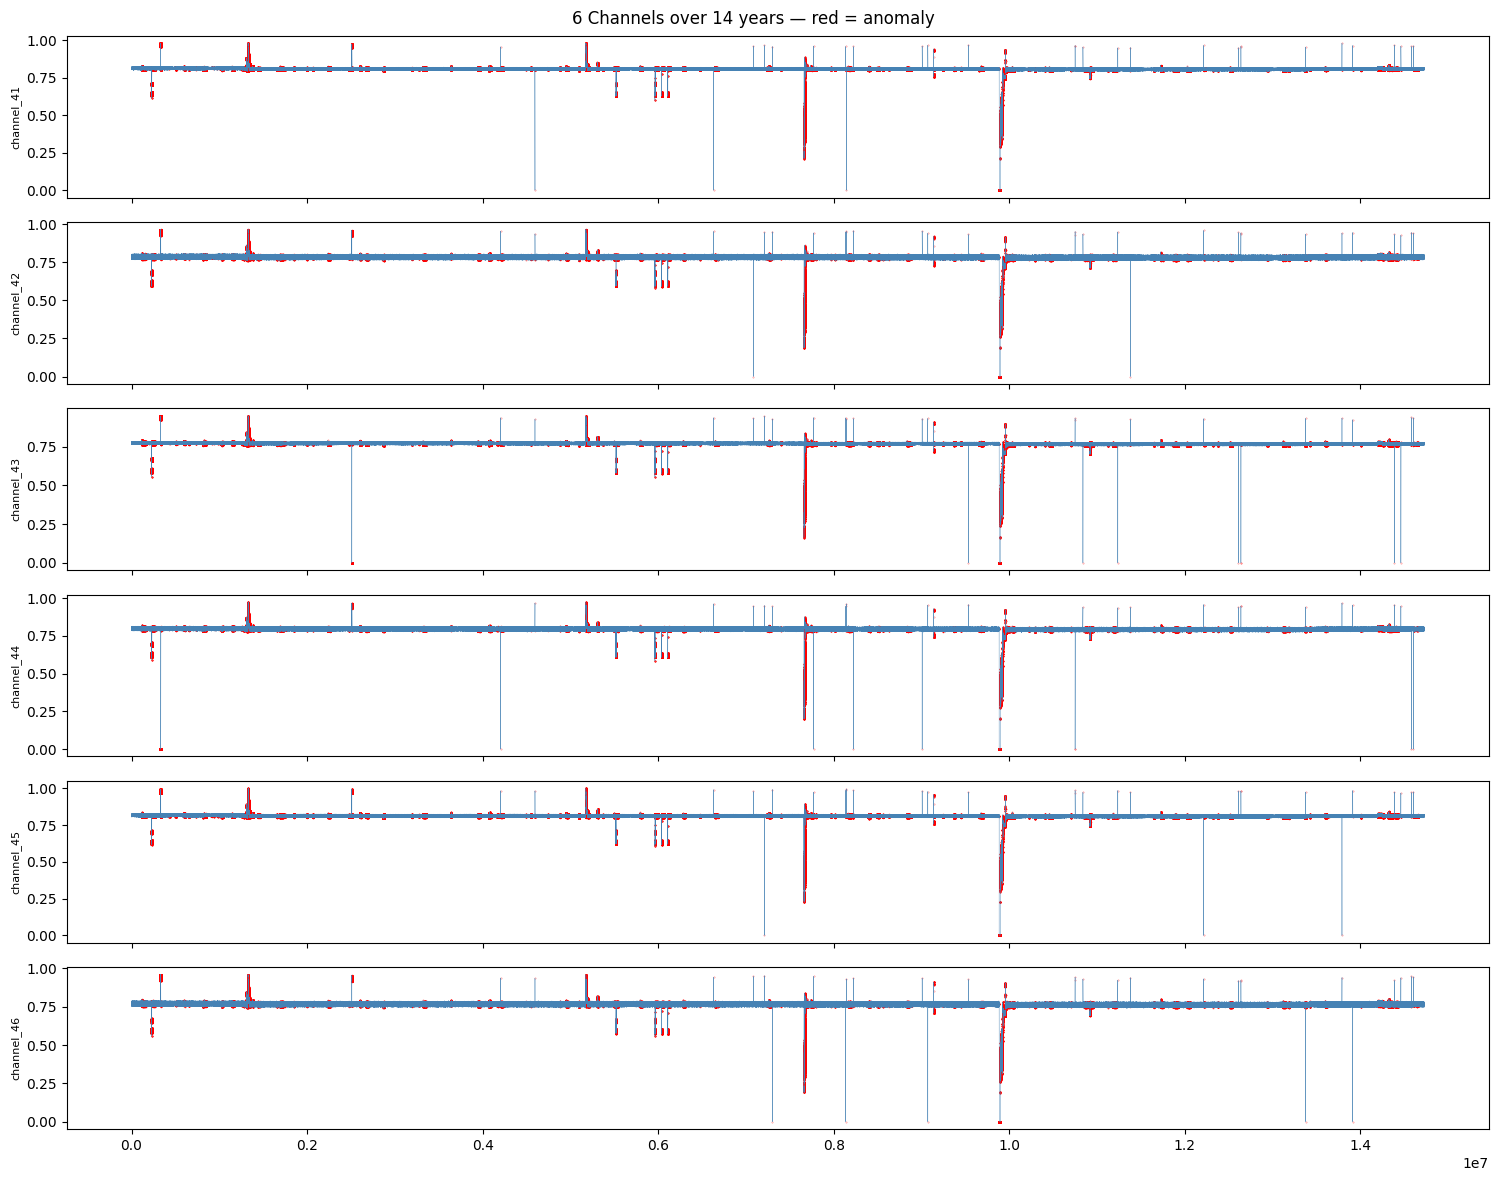

In [9]:
fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True)

channels = ['channel_41', 'channel_42', 'channel_43',
            'channel_44', 'channel_45', 'channel_46']

for i, col in enumerate(channels):
    axes[i].plot(df_small['id'], df_small[col], linewidth=0.3, color='steelblue')
    # Highlight anomalies in red
    anomalies = df_small[df_small['is_anomaly'] == 1]
    axes[i].scatter(anomalies['id'], anomalies[col],
                    color='red', s=0.1, alpha=0.5)
    axes[i].set_ylabel(col, fontsize=8)

plt.suptitle('6 Channels over 14 years — red = anomaly')
plt.tight_layout()
plt.show()